In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

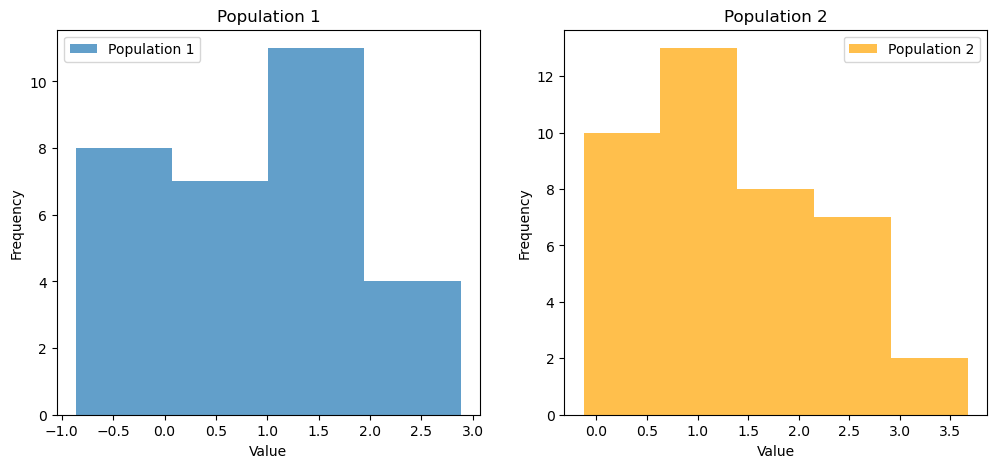

In [ ]:
# Data generation and visualization
sample1_size = 30
sample2_size = 40

population1_mean = 1
population2_mean = 1.2

population1 = np.random.randn(sample1_size) + population1_mean
population2 = np.random.randn(sample2_size) + population2_mean

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(population1, bins='fd', alpha=0.7, label='Population 1')
ax1.set_title('Population 1')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')
ax1.legend()

ax2.hist(population2, bins='fd', alpha=0.7, label='Population 2', color='orange')
ax2.set_title('Population 2')
ax2.set_xlabel('Value')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.show()



In [ ]:
# Calculating the t-statistic and p-value
t, p = stats.ttest_ind(population1, population2, equal_var=True)
display(f't-value and p-value from scipy:  {t} {p}')

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(80, 100))

Degrees of freedom: 68, t-value: -1.7750678402429416, p-value: 0.08036188773576831


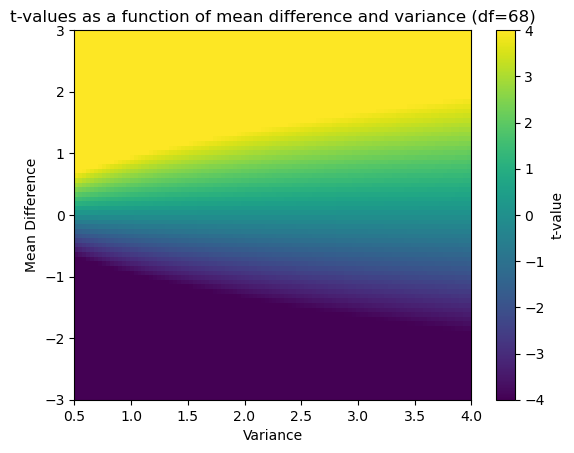

In [ ]:
# Plotting t-values as a function of mean difference and variance
df = sample1_size + sample2_size - 2
mean_differences = np.linspace(-3, 3, 80)
pooled_variances = np.linspace(0.5, 4, 100)

allTValues = np.zeros((len(mean_differences), len(pooled_variances)))

print(f"Degrees of freedom: {df}, t-value: {t}, p-value: {p}")

for i in range(len(mean_differences)):
    for j in range(len(pooled_variances)):
        s = np.sqrt(( (sample1_size-1) * pooled_variances[j] + (sample2_size-1) * pooled_variances[j] ) / df)
        t_den = s * np.sqrt(1/sample1_size + 1/sample2_size)

        allTValues[i, j] = mean_differences[i] / t_den


plt.imshow(allTValues, vmin=-4, vmax=4, extent=[pooled_variances[0], pooled_variances[-1], mean_differences[0], mean_differences[-1]], aspect='auto', origin='lower')
plt.xlabel('Variance')
plt.ylabel('Mean Difference')
plt.colorbar(label='t-value')
plt.title(f't-values as a function of mean difference and variance (df={df})')
plt.show()

